Symmetry of chemistry objects
=========================

This notebook introduces the usage of posym to determine the symmetry of molecular orbitals and wave functions 

Setup environment
----------------------

Install required packages

In [146]:
try:
    import posym
except ImportError:
    ! pip install git+https://github.com/abelcarreras/posym.git
try:
    import pyscf
except ImportError:
    ! pip install pyscf
try:
    import matplotlib
except ImportError:
    ! pip install matplotlib

Import required modules

In [147]:
from posym import SymmetryMolecule, SymmetryGaussianLinear, SymmetrySingleDeterminant, SymmetryMultiDeterminant
from posym.tools import get_basis_set_pyscf, build_density, build_orbital
from pyscf import gto, scf, mcscf
import numpy as np
import matplotlib.pyplot as plt

Compute the electronic structure
---------------------------------------

Compute the electronic structure of the water molecule using pySCF

In [137]:
r = 1  # O-H distance
alpha = np.deg2rad(104.5)  # H-O-H angle

mol_pyscf = gto.M(atom=[['O', [0, 0, 0]],
                        ['H', [-r, 0, 0]],
                        ['H', [r*np.cos(np.pi - alpha), r*np.sin(np.pi - alpha), 0]]],
                  basis='3-21g',
                  charge=0,
                  spin=0)

In [138]:
pyscf_scf = scf.RHF(mol_pyscf).run()

converged SCF energy = -75.5839822753811


Extract the molecular orbitals

In [139]:
mo_coefficients = pyscf_scf.mo_coeff.T
overlap_matrix = pyscf_scf.get_ovlp(mol_pyscf)

Properties of the molecule

In [140]:
print('n_atoms: ', mol_pyscf.natm)
print('n_orbitals: ', mol_pyscf.nao)
print('n_electrons: ', mol_pyscf.nelectron)

n_atoms:  3
n_orbitals:  13
n_electrons:  10


Geometry symmetry
-----------------

Analyze the symmetry of the molecular structure

In [117]:
geom_sym = SymmetryMolecule('c2v', mol_pyscf.atom_coords(), [mol_pyscf.atom_symbol(i) for i in range(mol_pyscf.natm)])
print('geometry CSM: {:6.3f}'.format(geom_sym.measure))

geometry CSM:  0.000


Molecular orbitals symmetry
---------------------------

Obtain the basis functions to construct the molecular orbitals

In [118]:
basis_set = get_basis_set_pyscf(mol_pyscf)

Construct the molecular orbitals from the basis functions and the MO coefficients

In [120]:
orbitals = []
for i, orbital_vect in enumerate(mo_coefficients):
    orb = build_orbital(basis_set, orbital_vect)
    orbitals.append(orb)

Plot the molecular orbitals

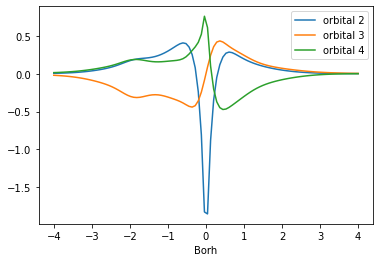

In [134]:
xrange = np.linspace(-4, 4, 100)
yrange = np.zeros_like(xrange)
zrange = np.zeros_like(xrange)

orbital_2 = orbitals[1]
orbital_3 = orbitals[2]
orbital_4 = orbitals[3]

plt.plot(xrange, orbital_2(xrange, yrange, zrange), label='orbital 2')
plt.plot(xrange, orbital_3(xrange, yrange, zrange), label='orbital 3')
plt.plot(xrange, orbital_4(xrange, yrange, zrange), label='orbital 4')
plt.xlabel('Borh')
plt.legend()

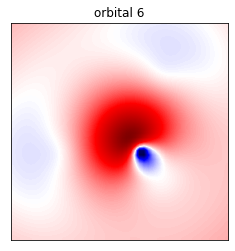

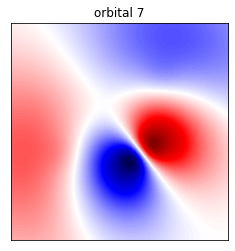

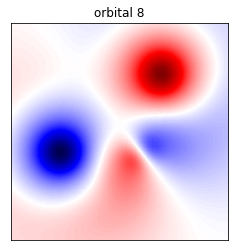

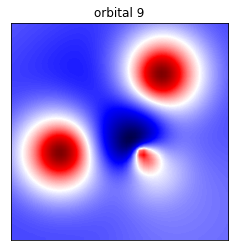

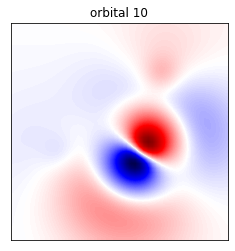

<Figure size 432x288 with 0 Axes>

In [122]:
x = np.linspace(-3, 2, 50)
y = np.linspace(-2, 3, 50)

X, Y = np.meshgrid(x, y)

for i, orbital in enumerate(orbitals):
    if i < 5 or i > 9:
        continue
    Z = orbital(X, Y, np.zeros_like(X))
    plt.imshow(Z, interpolation='bilinear', origin='lower', cmap='seismic')
    plt.title('orbital {}'.format(i+1))
    plt.xticks([])
    plt.yticks([])
    plt.figure()

Determine the symmetry of the molecular orbitals

In [123]:
sym_orbitals = []
for i, orbital in enumerate(orbitals):
    sym_orb = SymmetryGaussianLinear('c2v', orbital,
                                     orientation_angles=geom_sym.orientation_angles,
                                     center=geom_sym.center
                                     )
    sym_orbitals.append(sym_orb)
    print('orbital {}: {}'.format(i+1, sym_orb))

orbital 1: A1
orbital 2: A1
orbital 3: B1
orbital 4: A1
orbital 5: B2
orbital 6: A1
orbital 7: B1
orbital 8: B1
orbital 9: A1
orbital 10: B2
orbital 11: A1
orbital 12: B1
orbital 13: A1


Wave function symmetry
----------------------

In [104]:
wf_alpha = sym_orbitals[7] * sym_orbitals[8] * sym_orbitals[9]
wf_beta = sym_orbitals[7] * sym_orbitals[8] * sym_orbitals[9]
wf_sym = wf_alpha * wf_beta

print('Configuration 1: ', wf_sym)

Configuration 1:  A1


In [105]:
wf_alpha = sym_orbitals[7] * sym_orbitals[8] * sym_orbitals[9]
wf_beta = sym_orbitals[7] * sym_orbitals[8] * sym_orbitals[10]
wf_sym = wf_alpha * wf_beta

print('Configuration 2: ', wf_sym)

Configuration 2:  B2


In [93]:
wf_sym = SymmetrySingleDeterminant('c2v',
                                   alpha_orbitals=[orbitals[7], orbitals[8], orbitals[9]],
                                   beta_orbitals=[orbitals[7], orbitals[8], orbitals[9]])
print('Configuration 1: ', wf_sym)

Configuration 1:  A1


In [96]:
wf_sym = SymmetrySingleDeterminant('c2v',
                                   alpha_orbitals=[orbitals[7], orbitals[8], orbitals[9]],
                                   beta_orbitals=[orbitals[7], orbitals[8], orbitals[10]])
print('Configuration 2: ', wf_sym)

Configuration 2:  B2


Electronic density symmetry
----------------------------

In [143]:
density_matrix_mo = np.diag([2.0]*(mol_pyscf.nelectron//2) + [0.0]*(mol_pyscf.nao-mol_pyscf.nelectron//2))
print(density_matrix_mo)
density_matrix_ao = mo_coefficients.T @ density_matrix_mo @ mo_coefficients

[[2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [144]:
f_density = build_density(basis_set, density_matrix_ao)

print('\ndensity integral: {:5.2f}'.format(f_density.integrate))

sm_dens = SymmetryGaussianLinear('c2v', f_density,
                                 orientation_angles=geom_sym.orientation_angles,
                                 center=geom_sym.center
                                 )
print(sm_dens)


density integral: 10.00
A1


Excited states
--------------

In [ ]:
# compute excited states with CAS
ncas = 2
nelecas = 2
mc = mcscf.CASCI(pyscf_scf, ncas, nelecas)
mc.fcisolver.nroots = 3

energy, _, ci_vectors, _, _ = mc.kernel()

Get the configuration that corresponds to each ci_vector

In [ ]:
from pyscf.fci import cistring

ncas = mc.ncas
nelecas = mc.nelecas
nfrozen = ncore = (mol_pyscf.nelectron - sum(nelecas)) // 2

# number of electrons α and β in active space
na = nelecas[0] if isinstance(nelecas, tuple) else nelecas // 2
nb = nelecas[1] if isinstance(nelecas, tuple) else nelecas // 2

# generate all configurations as integers (bitstrings)
alpha_strs = cistring.make_strings(range(ncas), na)
beta_strs  = cistring.make_strings(range(ncas), nb)

Get the configurations (slater determinants) that compose each state

In [ ]:
tolerance = 1e-2
states = []
for i, ci_vector in enumerate(ci_vectors):
    print('\nState: {} {}'.format(i+1, energy[i]))

    configurations = []
    for i, a in enumerate(alpha_strs):
        for j, b in enumerate(beta_strs):
            coeff = ci_vector[i, j]
            if abs(coeff) > tolerance:
                occ_a = format(a, f'0{ncas}b')
                occ_b = format(b, f'0{ncas}b')
                print(f"α: {occ_a}  β: {occ_b}   coeff = {coeff:+.4f}")

                vect_a = [1] * nfrozen + [1 if c == '1' else 0 for c in occ_a]
                vect_b = [1] * nfrozen + [1 if c == '1' else 0 for c in occ_b]
                configurations.append({'amplitude': float(coeff),
                                       'occupations': {'alpha': vect_a,
                                                       'beta': vect_b}
                                       })
    states.append(configurations)

Determine the symmetry of each muti-configurational state

In [ ]:
for i, conf in enumerate(states):
    wf_sym = SymmetryMultiDeterminant('C2v',
                                      orbitals=orbitals[:nfrozen + ncas],
                                      configurations=conf)

    print('State {}: {}'.format(i+1, wf_sym))